In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Part 1 – Data Exploration

In [5]:
df= pd.read_csv("diabetes.csv")

In [6]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [7]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [8]:
df['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


In [9]:
"""
target => 'Outcome'
problem => classification 0 or 1
objictives => most likely all of them
"""

"\ntarget => 'Outcome'\nproblem => classification 0 or 1\nobjictives => most likely all of them\n"

In [10]:
df.shape #data is too small

(768, 9)

In [11]:
#Display the dataset structure using .info() and .describe().
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [12]:
"""
no null data and till now they all look numeric cols except for the outcome
"""

'\nno null data and till now they all look numeric cols except for the outcome\n'

In [13]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [14]:
"""
Pregnancies has outliers aboe the upper boundry
all the features might have outliers above the upper bound

distribution: (not sure)
1. normal distribute : Pregnancies , Glucose , BloodPressure , SkinThickness , BMI ,
2. skewed: Insulin , Age
DiabetesPedigreeFunction => I do not know yet

"""

'\nPregnancies has outliers aboe the upper boundry\nall the features might have outliers above the upper bound\n\ndistribution: (not sure)\n1. normal distribute : Pregnancies , Glucose , BloodPressure , SkinThickness , BMI ,\n2. skewed: Insulin , Age\nDiabetesPedigreeFunction => I do not know yet\n\n'

<Axes: xlabel='Outcome', ylabel='count'>

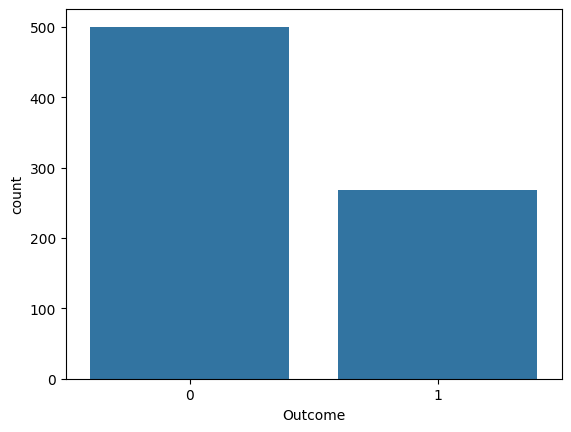

In [15]:
#Visualize the distribution of the target variable.
sns.countplot(data=df, x="Outcome")

In [16]:
"""
target imbalanced
"""

'\ntarget imbalanced\n'

<Axes: >

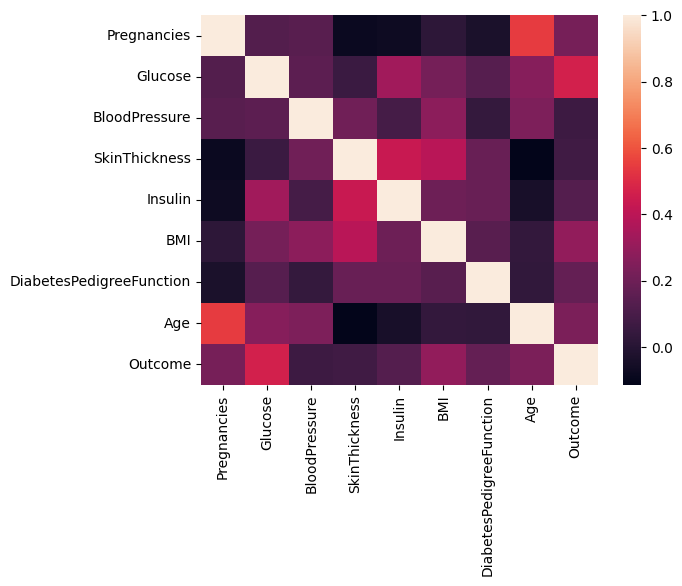

In [17]:
#Create a correlation heatmap.
sns.heatmap(df.corr())

In [18]:
df.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


In [19]:
"""
Glucose medium relation with outcome
Insulin has medium relation with SkinThickness
Pregnancies mid relation with Pregnancies
"""

'\nGlucose medium relation with outcome\nInsulin has medium relation with SkinThickness\nPregnancies mid relation with Pregnancies\n'

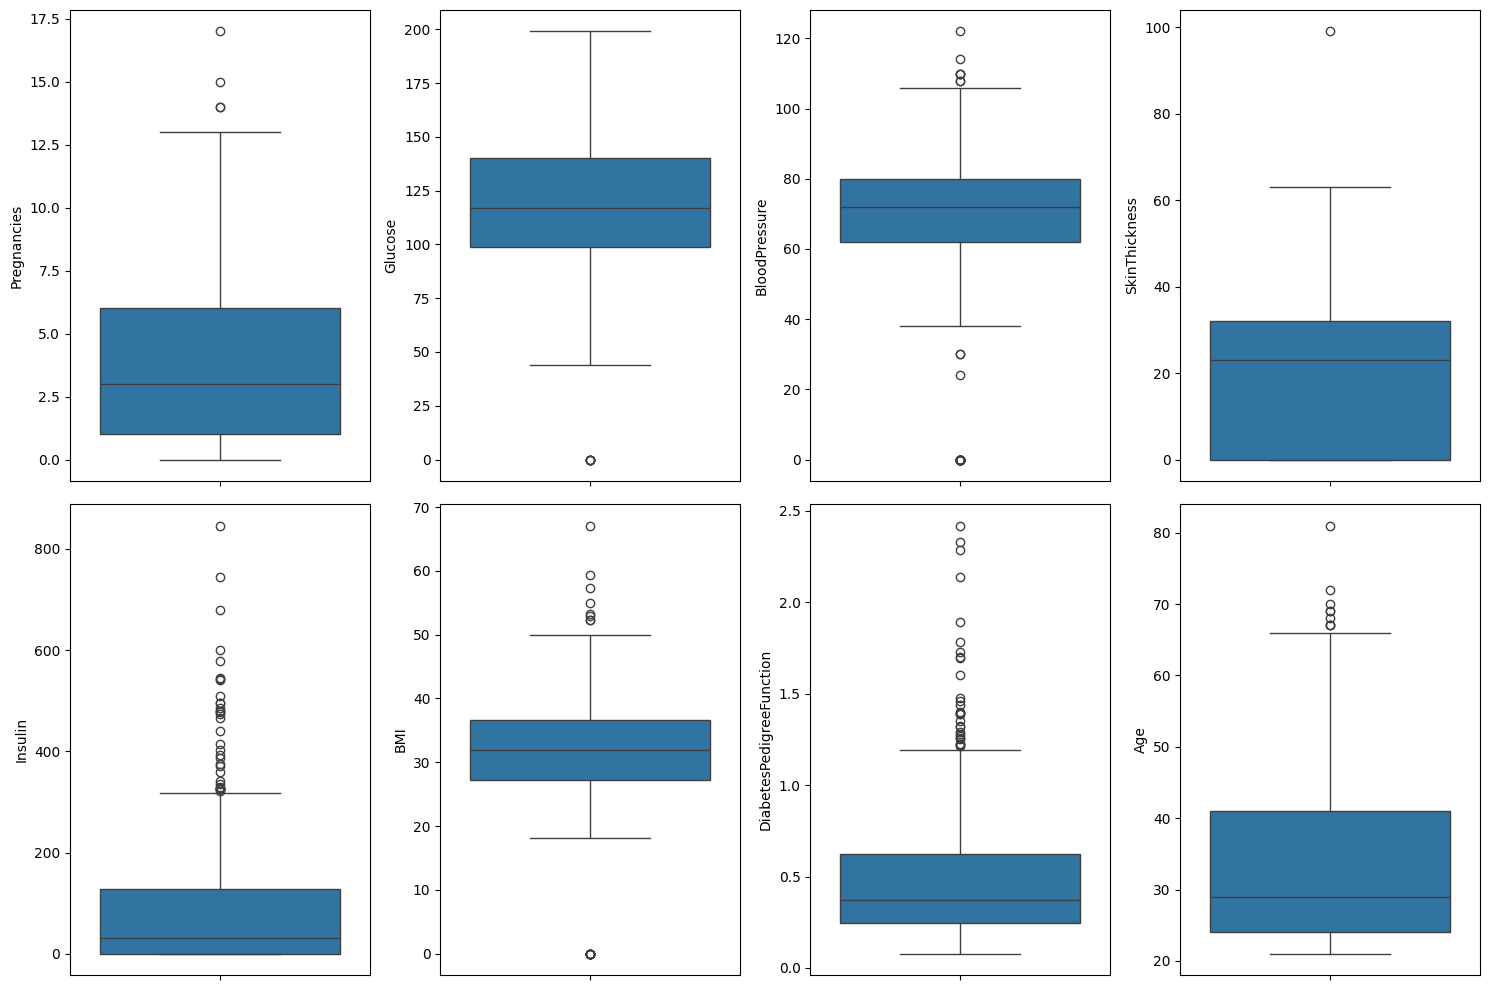

In [20]:
#Identify invalid values.
cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age']
fig = plt.figure(figsize=(15,10) )

for i,col in enumerate(cols,start=1):
  fig.add_subplot(2,4,i)
  sns.boxplot(data=df , y=col)
plt.tight_layout()
plt.show()

In [21]:
colsUpperOuliers = ['Pregnancies','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']
colsLowOutliers = ['Glucose', 'BloodPressure','BMI']

In [22]:
colsToImpute = ['Glucose', 'BloodPressure','BMI','Insulin',]

In [23]:
"""
the colsLowOutliers = ['Glucose', 'BloodPressure','BMI'] are zero does not make sence so they will be imputed
"""

"\nthe colsLowOutliers = ['Glucose', 'BloodPressure','BMI'] are zero does not make sence so they will be imputed\n"

In [24]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [25]:
"""
ooh boy that is so many outliers for such a small dataset,
this dataset would never work in real life specialy it is a medical data
"""

'\nooh boy that is so many outliers for such a small dataset,\nthis dataset would never work in real life specialy it is a medical data\n'

In [26]:
def outliers(data , col):
  Q1 = data[col].quantile(0.25)
  Q3 = data[col].quantile(0.75)
  IQR = Q3 - Q1
  lowbound = Q1 - 1.5 * IQR
  upperbound = Q3 + 1.5 * IQR
  return lowbound , upperbound

In [27]:
lowAge , upperAge = outliers(df,'Age')
df[df['Age']>upperAge]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
123,5,132,80,0,0,26.8,0.186,69,0
363,4,146,78,0,0,38.5,0.520,67,1
453,2,119,0,0,0,19.6,0.832,72,0
459,9,134,74,33,60,25.9,0.460,81,0
489,8,194,80,0,0,26.1,0.551,67,0
537,0,57,60,0,0,21.7,0.735,67,0
666,4,145,82,18,0,32.5,0.235,70,1
674,8,91,82,0,0,35.6,0.587,68,0
684,5,136,82,0,0,0.0,0.640,69,0


In [28]:
"""
Ages ouliers make since it is a  medical data but most of them do not have chance to develop diabetes most likely because the already have it
but their corrisposding insulin level are 0
also it might be missleading
"""

'\nAges ouliers make since it is a  medical data but most of them do not have chance to develop diabetes most likely because the already have it\nbut their corrisposding insulin level are 0\nalso it might be missleading\n'

In [29]:
lowPreg , highPreg = outliers(df, 'Pregnancies')
df[df['Pregnancies']>highPreg]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
88,15,136,70,32,110,37.1,0.153,43,1
159,17,163,72,41,114,40.9,0.817,47,1
298,14,100,78,25,184,36.6,0.412,46,1
455,14,175,62,30,0,33.6,0.212,38,1


In [30]:
"""
otliers for number of Pregnancies also make sense, since there are some people who really have this many pregnencies
and also all of them will develop diabetes
"""

'\notliers for number of Pregnancies also make sense, since there are some people who really have this many pregnencies\nand also all of them will develop diabetes\n'

In [31]:
lowSkin , upperSkin = outliers(df,'SkinThickness')
df[df['SkinThickness'] > upperSkin]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
579,2,197,70,99,0,34.7,0.575,62,1


In [32]:
"""
just 1 value does not make sense , will be imputed
"""

'\njust 1 value does not make sense , will be imputed\n'

In [33]:
lowblood , upperblood = outliers(df,"BloodPressure" )

In [34]:
"""
When High Blood Pressure Becomes Deadly
Hypertensive Crisis: A sudden spike over 180/110
"""

'\nWhen High Blood Pressure Becomes Deadly\nHypertensive Crisis: A sudden spike over 180/110\n'

In [35]:
180/110

1.6363636363636365

In [36]:
df[df['BloodPressure']>upperblood]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
43,9,171,110,24,240,45.4,0.721,54,1
84,5,137,108,0,0,48.8,0.227,37,1
106,1,96,122,0,0,22.4,0.207,27,0
177,0,129,110,46,130,67.1,0.319,26,1
362,5,103,108,37,0,39.2,0.305,65,0
549,4,189,110,31,0,28.5,0.680,37,0
691,13,158,114,0,0,42.3,0.257,44,1


In [37]:
"""
from what I searched , these are possible blood pressure
"""

'\nfrom what I searched , these are possible blood pressure\n'

In [38]:
df[df['BloodPressure']<lowblood]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
7,10,115,0,0,0,35.3,0.134,29,0
15,7,100,0,0,0,30.0,0.484,32,1
18,1,103,30,38,83,43.3,0.183,33,0
49,7,105,0,0,0,0.0,0.305,24,0
60,2,84,0,0,0,0.0,0.304,21,0
78,0,131,0,0,0,43.2,0.270,26,1
81,2,74,0,0,0,0.0,0.102,22,0
125,1,88,30,42,99,55.0,0.496,26,1
172,2,87,0,23,0,28.9,0.773,25,0
193,11,135,0,0,0,52.3,0.578,40,1


In [39]:
"""
The Dangerous Zones90/60 mmHg:
The formal entry point for low blood pressure (hypotension). For some thin or athletic individuals, this is their
normal, healthy baseline. It only becomes dangerous
"""

'\nThe Dangerous Zones90/60 mmHg:\nThe formal entry point for low blood pressure (hypotension). For some thin or athletic individuals, this is their\nnormal, healthy baseline. It only becomes dangerous\n'

In [40]:
""" it make sense except for the zero values"""

' it make sense except for the zero values'

In [41]:
"""
BMI is no longer accurate in medical diagnoses since it was created using white adult men data so I will drop it
"""

'\nBMI is no longer accurate in medical diagnoses since it was created using white adult men data so I will drop it\n'

In [42]:
lowIns , upperIns = outliers(df,'Insulin')
df[df['Insulin']>upperIns]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
8,2,197,70,45,543,30.5,0.158,53,1
13,1,189,60,23,846,30.1,0.398,59,1
54,7,150,66,42,342,34.7,0.718,42,0
111,8,155,62,26,495,34.0,0.543,46,1
139,5,105,72,29,325,36.9,0.159,28,0
153,1,153,82,42,485,40.6,0.687,23,0
186,8,181,68,36,495,30.1,0.615,60,1
220,0,177,60,29,478,34.6,1.072,21,1
228,4,197,70,39,744,36.7,2.329,31,0
231,6,134,80,37,370,46.2,0.238,46,1


In [43]:
"""
Normal vs. High RangesOptimal
1. Fasting Insulin: Normally between 2.6 and 24.9 μIU/mL
though many functional medicine experts prefer it below 6 to 10 μIU/mL

2. Critical / High Thresholds: Levels above 30 μIU/mL
are typically flagged as critically high or indicative of severe

Unit | TypeLow/Normal Level | Very High Level
*μIU/mL | 5 μIU/mL           |  150 μIU/mL* => most likely what is used in the dataset
pmol/L | 30 pmol/L          |  900 pmol/L
"""

'\nNormal vs. High RangesOptimal\n1. Fasting Insulin: Normally between 2.6 and 24.9 μIU/mL\nthough many functional medicine experts prefer it below 6 to 10 μIU/mL\n\n2. Critical / High Thresholds: Levels above 30 μIU/mL\nare typically flagged as critically high or indicative of severe\n\nUnit | TypeLow/Normal Level | Very High Level\n*μIU/mL | 5 μIU/mL           |  150 μIU/mL* => most likely what is used in the dataset\npmol/L | 30 pmol/L          |  900 pmol/L\n'

In [44]:
"""these are impossiple data for insulin and in the outliers that are higher than uupper bound there might be using
 pmol/L instead of μIU/mL like the rest of the data """

'these are impossiple data for insulin and in the outliers that are higher than uupper bound there might be using\n pmol/L instead of μIU/mL like the rest of the data '

In [45]:
df[(df['Insulin']<upperIns) & (df['Insulin'] != 0)].sort_values(by="Insulin")

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
445,0,180,78,63,14,59.4,2.420,25,1
617,2,68,62,13,15,20.1,0.257,23,0
760,2,88,58,26,16,28.4,0.766,22,0
108,3,83,58,31,18,34.3,0.336,25,0
566,1,99,72,30,18,38.6,0.412,21,0
...,...,...,...,...,...,...,...,...,...
606,1,181,78,42,293,40.0,1.258,22,1
53,8,176,90,34,300,33.7,0.467,58,1
56,7,187,68,39,304,37.7,0.254,41,1
412,1,143,84,23,310,42.4,1.076,22,0


In [46]:
"""for insulin col the data will be converted from μIU/mL to pmol/L"""

'for insulin col the data will be converted from μIU/mL to pmol/L'

In [47]:
""" The highest possible Diabetes Pedigree Function (DPF) value recorded in the standard Pima Indians Diabetes
 Dataset is 2.42"""

' The highest possible Diabetes Pedigree Function (DPF) value recorded in the standard Pima Indians Diabetes\n Dataset is 2.42'

In [48]:
lowDia , upperDia = outliers(df,'DiabetesPedigreeFunction')
df[df['DiabetesPedigreeFunction']>upperDia]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
4,0,137,40,35,168,43.1,2.288,33,1
12,10,139,80,0,0,27.1,1.441,57,0
39,4,111,72,47,207,37.1,1.390,56,1
45,0,180,66,39,0,42.0,1.893,25,1
58,0,146,82,0,0,40.5,1.781,44,0
100,1,163,72,0,0,39.0,1.222,33,1
147,2,106,64,35,119,30.5,1.400,34,0
187,1,128,98,41,58,32.0,1.321,33,1
218,5,85,74,22,0,29.0,1.224,32,1
228,4,197,70,39,744,36.7,2.329,31,0


In [49]:
"these are possible"

'these are possible'

In [50]:
lowGlu , upperGlu = outliers(df , "Glucose")
df[df['Glucose']<lowGlu]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
75,1,0,48,20,0,24.7,0.140,22,0
182,1,0,74,20,23,27.7,0.299,21,0
342,1,0,68,35,0,32.0,0.389,22,0
349,5,0,80,32,0,41.0,0.346,37,1
502,6,0,68,41,0,39.0,0.727,41,1


In [51]:
"impute zeros in Glucose"

'impute zeros in Glucose'

In [52]:
df['Pregnancies'].value_counts().count()

np.int64(17)

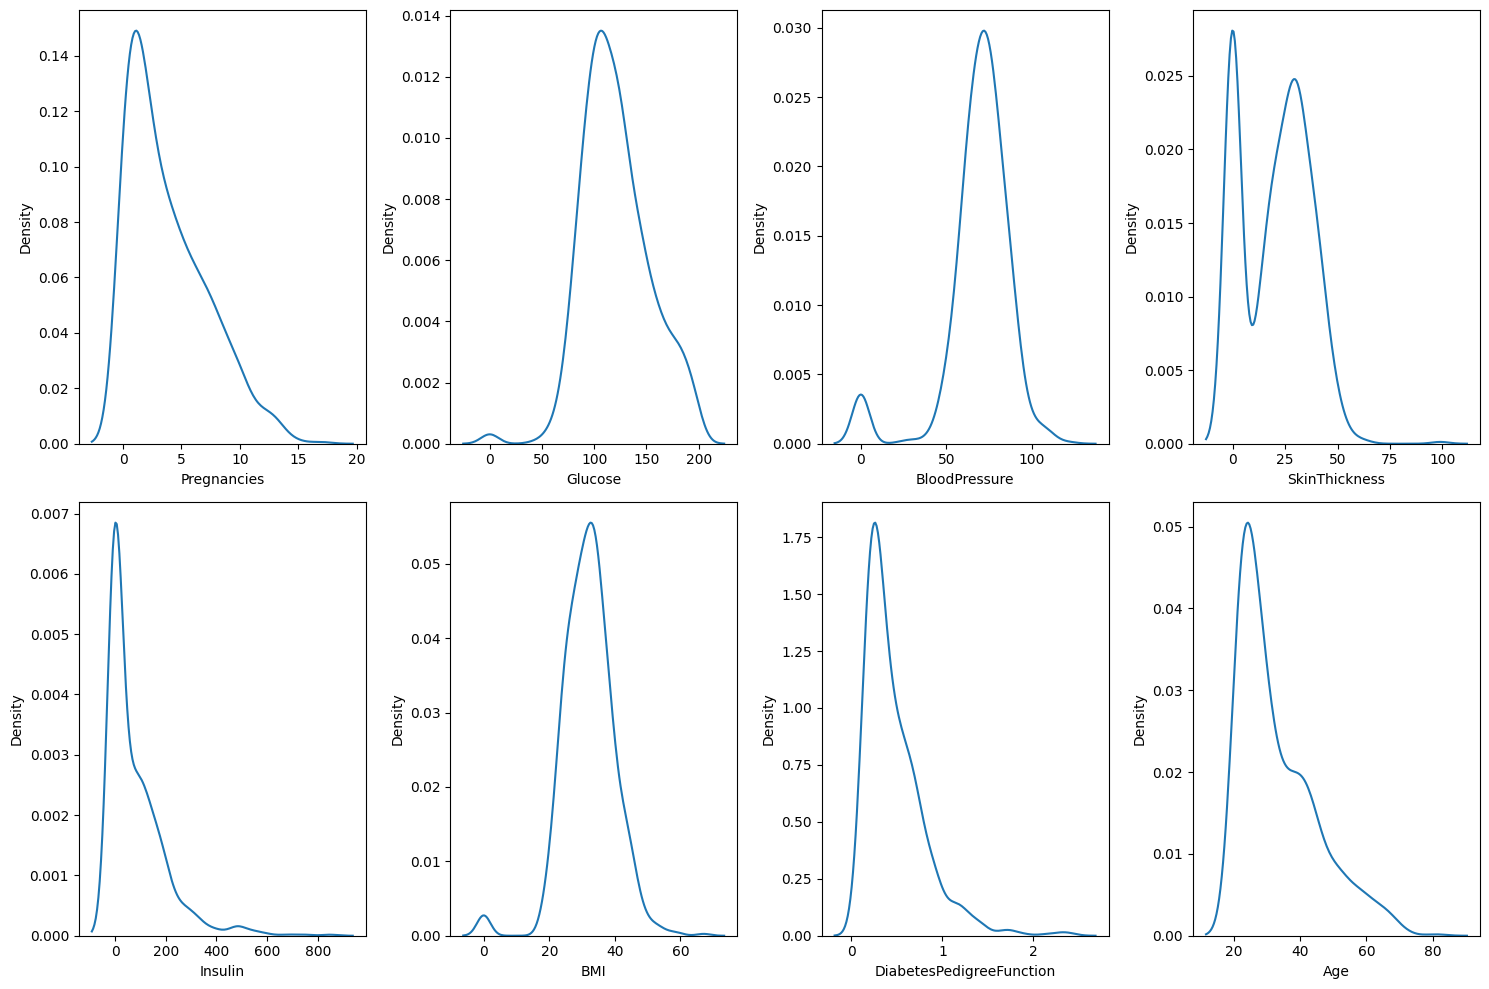

In [53]:
fig = plt.figure(figsize=(15,10) )

for i,col in enumerate(cols,start=1):
  fig.add_subplot(2,4,i)
  sns.kdeplot(data=df , x=col)
plt.tight_layout()
plt.show()

In [54]:
df['SkinThickness'].value_counts().count()

np.int64(51)

In [55]:
"""
skin => impute upper
blood => impute zero vals
Glucose => Glucose
Insulin = > impute upper from μIU/mL to pmol/L
BMI => Drop
"""

'\nskin => impute upper\nblood => impute zero vals\nGlucose => Glucose\nInsulin = > impute upper from μIU/mL to pmol/L\nBMI => Drop\n'

In [56]:
#Identify missing values
# from info up no missing but lets check
df.isna().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [57]:
""" instead of null data we have zero innstead"""

' instead of null data we have zero innstead'

In [58]:
df.duplicated().sum()

np.int64(0)

#Part 2 – Data Cleaning

In [59]:
# Identify features that contain invalid values
"""
skin => impute upper
blood => impute zero vals
Glucose => impute zero vals
Insulin = > impute upper : To convert insulin levels from pmol/L to µIU/mL, divide your pmol/L value by 6.945
BMI => Drop
"""

'\nskin => impute upper\nblood => impute zero vals\nGlucose => impute zero vals\nInsulin = > impute upper : To convert insulin levels from pmol/L to µIU/mL, divide your pmol/L value by 6.945\nBMI => Drop\n'

In [60]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [61]:
# we will use median to impute since the data is skewed
impColMed = ['SkinThickness','BloodPressure','Glucose']

In [62]:
bloodMed = df['BloodPressure'].median()
df.loc[df['BloodPressure'] == 0 ,'BloodPressure'] = bloodMed

In [63]:
gluMed =df['Glucose'].median()
df.loc[df['Glucose']==0 , "Glucose"] = gluMed

In [64]:
skinMed = df['SkinThickness'].median()
df.loc[df['SkinThickness'] > upperSkin , 'SkinThickness'] = skinMed

In [65]:
# df['Insulin'] = np.where(df['Insulin'] > upperIns , df['Insulin']/6.945 , df['Insulin'] > upperIns) #it mised up the data

In [66]:
df.loc[df['Insulin'] > upperIns , 'Insulin'] = df['Insulin'].median()

/tmp/ipykernel_10387/341239780.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '30.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['Insulin'] > upperIns , 'Insulin'] = df['Insulin'].median()


In [67]:
#convert data types
cols = ['Glucose','SkinThickness','Insulin','BloodPressure']
for col in cols:
  df[col]=df[col].astype(int)

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


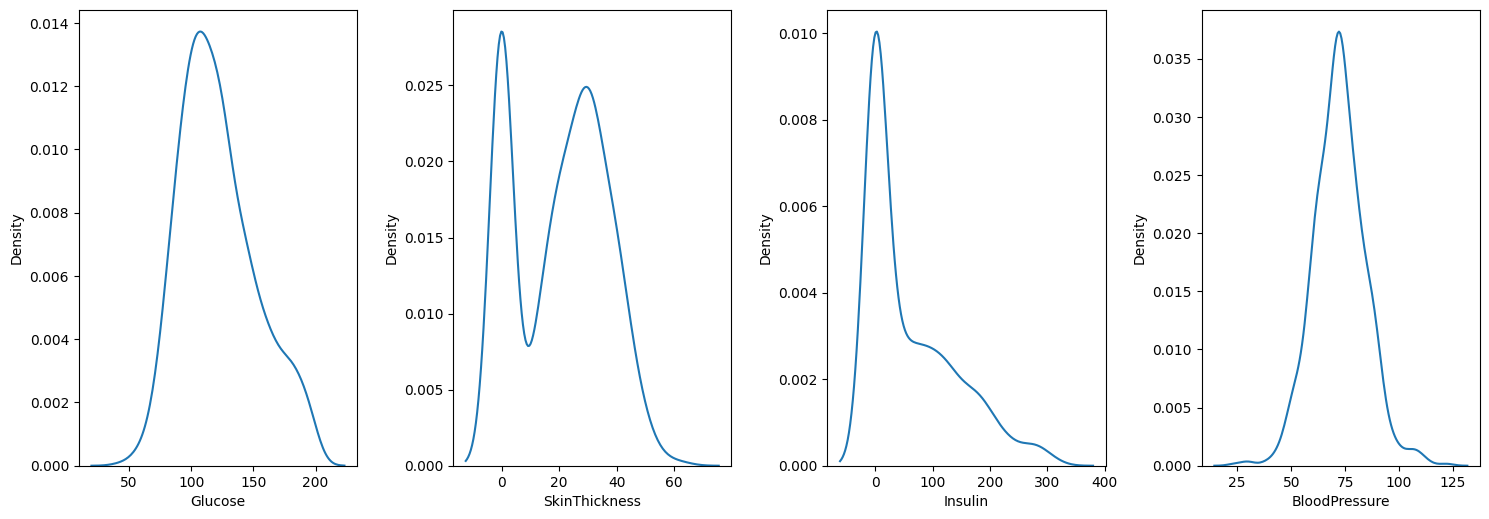

In [69]:
fig = plt.figure(figsize=(15,10) )

for i,col in enumerate(cols,start=1):
  fig.add_subplot(2,4,i)
  sns.kdeplot(data=df , x=col)
plt.tight_layout()
plt.show()

#Data Splitting and Feature Engineering

In [70]:
df['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


In [71]:
X = df.drop(columns=['Outcome','BMI'], axis=1)
Y = df['Outcome']

In [72]:
Y.value_counts(normalize=True)

,proportion
Outcome,
0,0.651042
1,0.348958


In [73]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(X,Y, test_size = 0.2 ,stratify = Y, random_state = 42)

In [74]:
y_train.value_counts(normalize=True)

,proportion
Outcome,
0,0.651466
1,0.348534


In [75]:
y_test.value_counts(normalize=True)

,proportion
Outcome,
0,0.649351
1,0.350649


In [76]:
x_train.shape , x_test.shape , y_train.shape , y_test.shape

((614, 7), (154, 7), (614,), (154,))

In [77]:
from sklearn.preprocessing import StandardScaler
std_scale = StandardScaler()

In [78]:
x_train.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'DiabetesPedigreeFunction', 'Age'],
      dtype='object')

In [79]:
cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'DiabetesPedigreeFunction', 'Age']

In [80]:
for col in cols:
  x_train[col] = std_scale.fit_transform(x_train[[col]])
  x_test[col] = std_scale.transform(x_test[[col]])

In [81]:
x_train

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,DiabetesPedigreeFunction,Age
353,-0.851355,-1.056427,-0.826740,-0.557344,-0.255663,0.310794,-0.792169
711,0.356576,0.144399,0.477772,0.408803,-0.528329,-0.116439,0.561034
373,-0.549372,-0.556083,-1.152868,1.246130,0.406524,-0.764862,-0.707594
46,-0.851355,0.811525,-1.315932,-1.330261,-0.813978,0.262314,-0.369293
682,-1.153338,-0.889646,-0.663676,1.181720,0.549349,-0.337630,-0.961320
...,...,...,...,...,...,...,...
451,-0.549372,0.411249,-0.174484,-1.330261,-0.813978,0.195653,-0.876744
113,0.054593,-1.523416,-0.826740,-1.330261,-0.813978,-0.261879,-0.707594
556,-0.851355,-0.822933,-0.174484,1.246130,-0.813978,-0.786072,-0.284718
667,1.866489,-0.355945,-0.174484,0.408803,-0.813978,-1.019383,0.561034


In [82]:
x_test

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,DiabetesPedigreeFunction,Age
44,0.960541,1.245157,-0.663676,-1.330261,-0.813978,-0.555791,0.561034
672,1.866489,-1.790266,2.760669,0.151164,-0.177759,-0.583061,1.153060
700,-0.549372,0.010974,0.314708,0.408803,1.782835,0.016882,-0.623019
630,0.960541,-0.255876,-0.663676,-1.330261,-0.813978,0.771356,0.053583
81,-0.549372,-1.590128,-0.011420,-1.330261,-0.813978,-1.137554,-0.961320
...,...,...,...,...,...,...,...
32,-0.247390,-1.123140,-1.152868,-0.621754,-0.112839,-0.637601,-0.961320
637,-0.549372,-0.923002,0.314708,-0.170885,0.042970,0.519865,-0.876744
593,-0.549372,-1.323278,-1.642060,0.086754,0.679189,3.701382,-0.707594
425,0.054593,2.079064,0.477772,1.181720,2.782608,-0.646691,-0.200143


#Part 4 – Model Training  

In [83]:
from sklearn.svm import SVC
svcLinear = SVC(kernel='linear')
svcPoly = SVC(kernel='poly')
svcRBF = SVC(kernel='rbf')

In [84]:
svcLinear.fit(x_train,y_train)

SVC(kernel='linear')

In [85]:
y_PredLinear = svcLinear.predict(x_test)

In [86]:
from sklearn.metrics import accuracy_score , classification_report
accuracy_score(y_test , y_PredLinear)

0.7337662337662337

In [87]:
print(classification_report(y_test , y_PredLinear))

              precision    recall  f1-score   support

           0       0.77      0.84      0.80       100
           1       0.64      0.54      0.59        54

    accuracy                           0.73       154
   macro avg       0.71      0.69      0.69       154
weighted avg       0.73      0.73      0.73       154



In [88]:
#since false negative is a big issue here since it is a medical data so

In [89]:
svcPoly.fit(x_train , y_train)

SVC(kernel='poly')

In [90]:
y_PredPoly = svcPoly.predict(x_test)

In [91]:
accuracy_score(y_test,y_PredPoly)

0.7012987012987013

In [92]:
print(classification_report(y_test , y_PredPoly))

              precision    recall  f1-score   support

           0       0.72      0.87      0.79       100
           1       0.62      0.39      0.48        54

    accuracy                           0.70       154
   macro avg       0.67      0.63      0.63       154
weighted avg       0.69      0.70      0.68       154



In [93]:
svcRBF.fit(x_train,y_train)

SVC()

In [94]:
y_Pred_RBF = svcRBF.predict(x_test)

In [95]:
accuracy_score(y_test , y_Pred_RBF)

0.7142857142857143

In [96]:
print(classification_report(y_test , y_Pred_RBF))

              precision    recall  f1-score   support

           0       0.77      0.80      0.78       100
           1       0.60      0.56      0.58        54

    accuracy                           0.71       154
   macro avg       0.68      0.68      0.68       154
weighted avg       0.71      0.71      0.71       154



#Part 5 – Hyperparameter Optimization

In [97]:
from sklearn.model_selection import GridSearchCV
params = {
    'kernel' : ['linear' , 'poly' , 'rbf'],
    'C' : [0.001 , 0.01 , 0.1,10] ,
    'gamma' : [0.001 , 0.01 , 0.1,1]
}
model = SVC()

In [98]:
grid = GridSearchCV(model , params)

In [99]:
grid.fit(x_train,y_train)

GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.001, 0.01, 0.1, 10],
                         'gamma': [0.001, 0.01, 0.1, 1],
                         'kernel': ['linear', 'poly', 'rbf']})

In [104]:
best_model = SVC(C=10, gamma=0.001, kernel='linear')

In [105]:
best_model.fit(x_train,y_train)

SVC(C=10, gamma=0.001, kernel='linear')

In [106]:
y_pred = best_model.predict(x_test)

In [107]:
accuracy_score(y_test , y_pred)

0.7337662337662337

In [108]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.77      0.84      0.80       100
           1       0.64      0.54      0.59        54

    accuracy                           0.73       154
   macro avg       0.71      0.69      0.69       154
weighted avg       0.73      0.73      0.73       154



In [112]:
"""
NOTE:

I used AI to help me with the following 2 part because I had no idea what I should do exactly
"""

'\nNOTE:\n\nI used AI to help me with the following 2 part because I had no idea what I should do exactly\n'

#Part 6 – Support Vector Analysis  

In [113]:
best_model.n_support_

array([164, 163], dtype=int32)

In [114]:
len(best_model.support_)

327

In [117]:
ratio = len(best_model.support_) / len(x_train)

In [118]:
ratio

0.5325732899022801

In [119]:
ratio * 100

53.25732899022802

In [130]:
" the support vectors are more than 50% of the training data"
"I do not know what it tells"

'I do not know what it tells'

#Part 7 – Model Robustness Test  

In [120]:
np.random.seed(42)

In [121]:
x_train_noisy = x_train.copy()

In [122]:
noise = np.random.normal(0,0.1 , size=len(x_train_noisy))

In [123]:
x_train_noisy['Glucose'] += noise

In [124]:
best_model.fit(x_train_noisy , y_train)

SVC(C=10, gamma=0.001, kernel='linear')

In [125]:
yPredNoisy = best_model.predict(x_test)

In [126]:
accuracy_score(y_test , yPredNoisy)

0.7337662337662337

In [127]:
print(classification_report(y_test,yPredNoisy))

              precision    recall  f1-score   support

           0       0.77      0.85      0.81       100
           1       0.65      0.52      0.58        54

    accuracy                           0.73       154
   macro avg       0.71      0.68      0.69       154
weighted avg       0.73      0.73      0.73       154



In [128]:
"the model is not sensitive to noises since the score did not change at all"

'the model is not sensitive to noises since the score did not change at all'